In [2]:
import src.utils as ut
import src.datasets as ds
from cdlib import algorithms
import networkx as nx

import numpy as np
import torch
import networkx as nx
import src.datasets as ds
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx, to_undirected
from torch_geometric.data import Data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
datasplit = ds.DataSplit("power", device, 1)
data, split = datasplit.get(0)

1 split from the dataset power


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.44it/s]


split time:  0.72  s
data 0:  Data(edge_index=[2, 9234], id=[4941], edge_id=[13188], edge__igraph_index=[13188], citation='['D.J. Watts and S.H. Strogatz, "Collective dynamics of \'small-world\' networks." Nature 393, 440-442 (1998)., http://www.nature.com/nature/journal/v393/n6684/abs/393440a0.html']', description='A network representing the Western States Power Grid of the United States, in which nodes are transforms or power relay points and two nodes are connected if a power line runs between them.', name='power', tags='Technological, Power grid, Unweighted', url='http://www-personal.umich.edu/~mejn/netdata/', num_nodes=4941, x=[4941, 4941], adj_t=[4941, 4941, nnz=9234], max_x=-1, full_adj_t=[4941, 4941, nnz=10552])
split 0:
train edge 4617
valid edge 659
valid edge_neg 659
test edge 1318
test edge_neg 1318


In [4]:
from sklearn.preprocessing import StandardScaler
pos = None
if hasattr(data, "_pos"):
    pos = []
    for p in data._pos:
        x, y = p.split(", ")
        pos.append([float(x), float(y)])
# else:
from torch_geometric.nn import Node2Vec
model = Node2Vec(
    data.edge_index,
    embedding_dim=32,
    walk_length=20,
    context_size=10,
    walks_per_node=10,
    num_negative_samples=1,
    p=1.0,
    q=1.0,
    sparse=True,
).to(device)

num_workers = 4
loader = model.loader(batch_size=128, shuffle=True, num_workers=num_workers)
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

def train():
    model.train()
    total_loss = 0
    for pos_rw, neg_rw in loader:
        optimizer.zero_grad()
        loss = model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)



for epoch in range(1, 50):
    loss = train()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')


Epoch: 001, Loss: 3.3125
Epoch: 002, Loss: 2.2151
Epoch: 003, Loss: 1.6760
Epoch: 004, Loss: 1.3845
Epoch: 005, Loss: 1.2099
Epoch: 006, Loss: 1.0994
Epoch: 007, Loss: 1.0214
Epoch: 008, Loss: 0.9700
Epoch: 009, Loss: 0.9319
Epoch: 010, Loss: 0.9023
Epoch: 011, Loss: 0.8796
Epoch: 012, Loss: 0.8619
Epoch: 013, Loss: 0.8480
Epoch: 014, Loss: 0.8370
Epoch: 015, Loss: 0.8274
Epoch: 016, Loss: 0.8196
Epoch: 017, Loss: 0.8125
Epoch: 018, Loss: 0.8076
Epoch: 019, Loss: 0.8025
Epoch: 020, Loss: 0.7985
Epoch: 021, Loss: 0.7950
Epoch: 022, Loss: 0.7921
Epoch: 023, Loss: 0.7888
Epoch: 024, Loss: 0.7867
Epoch: 025, Loss: 0.7848
Epoch: 026, Loss: 0.7834
Epoch: 027, Loss: 0.7811
Epoch: 028, Loss: 0.7800
Epoch: 029, Loss: 0.7785
Epoch: 030, Loss: 0.7775
Epoch: 031, Loss: 0.7764
Epoch: 032, Loss: 0.7754
Epoch: 033, Loss: 0.7746
Epoch: 034, Loss: 0.7741
Epoch: 035, Loss: 0.7733
Epoch: 036, Loss: 0.7725
Epoch: 037, Loss: 0.7720
Epoch: 038, Loss: 0.7713
Epoch: 039, Loss: 0.7707
Epoch: 040, Loss: 0.7709


In [5]:
fake_pos = torch.tensor(model())
pos = np.array(pos)
fake_pos = np.array(fake_pos.cpu())
pos = StandardScaler().fit_transform(pos)
fake_pos = StandardScaler().fit_transform(fake_pos)
fake_pos

array([[-0.15787022, -1.2049619 , -1.0445908 , ..., -0.80829006,
         0.3451133 , -0.08847403],
       [ 0.70390236,  0.27822277, -0.4386428 , ..., -0.04827637,
        -0.2987219 , -0.84875405],
       [ 0.11442225, -0.54077506, -1.1150752 , ...,  0.43776894,
         0.56234276,  1.37957   ],
       ...,
       [ 0.2686387 , -1.3681481 , -0.61791015, ...,  0.6980998 ,
        -0.33268717, -3.1186907 ],
       [ 0.08030313,  1.206708  ,  1.3685002 , ..., -0.11974182,
         0.13363153, -0.7611782 ],
       [-0.00464241,  1.1490513 ,  1.4533764 , ..., -0.12181471,
         0.10040621, -1.097135  ]], shape=(4941, 32), dtype=float32)

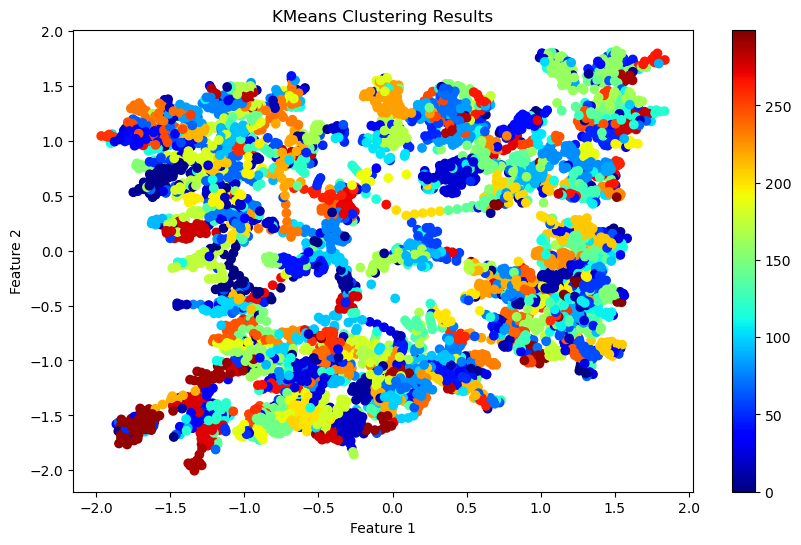

In [6]:
from sklearn.cluster import AgglomerativeClustering,KMeans

agglo = AgglomerativeClustering(n_clusters=300)
clusters = agglo.fit_predict(fake_pos)

kmeans = KMeans(n_clusters=300)
clusters_2 = kmeans.fit_predict(fake_pos)

# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pos[:, 0], pos[:, 1], c=clusters, cmap='jet')
plt.colorbar(scatter)
plt.title('KMeans Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

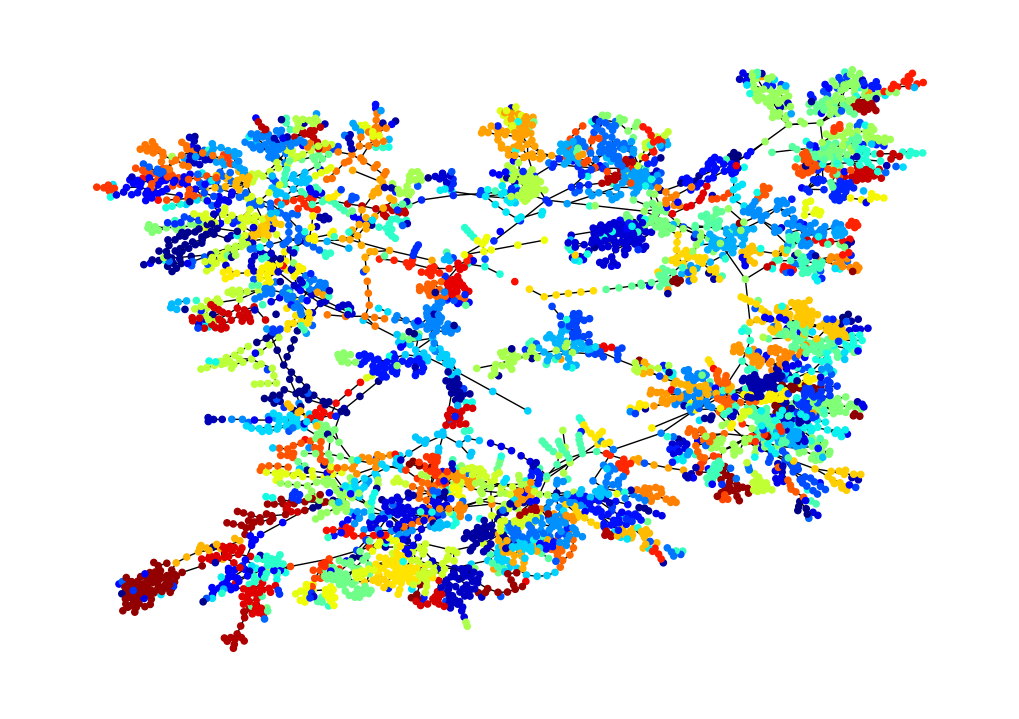

torch.Size([2, 9234])


In [7]:
def plot(data, commu, title= ""):
    G = to_networkx(data, to_undirected=True, remove_self_loops=True)
    color_map = {}
    plt.figure(figsize=(10, 7))
    nx.draw(G, node_size=20, pos=pos, node_color=commu, cmap=plt.cm.get_cmap('jet', len(commu)))
    # nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')
    plt.title(title)
    plt.show()
    print(data.edge_index.shape)
plot(data, clusters)

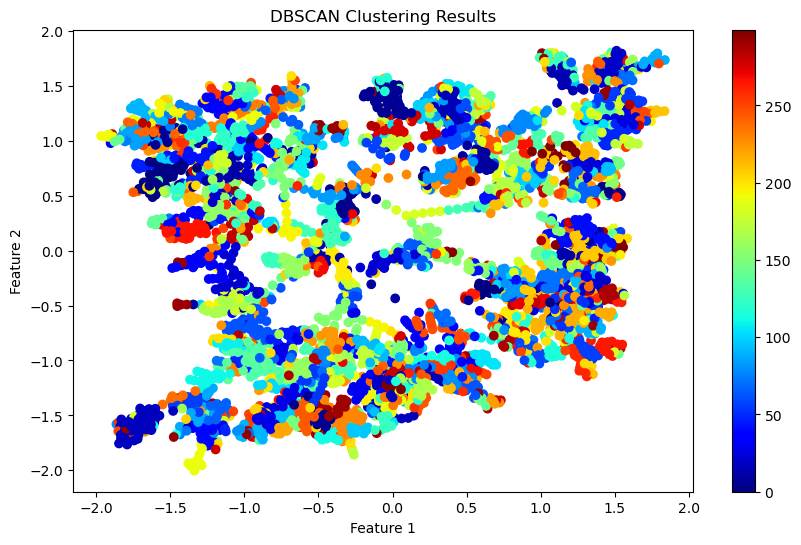

In [8]:
# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pos[:, 0], pos[:, 1], c=clusters_2, cmap='jet')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

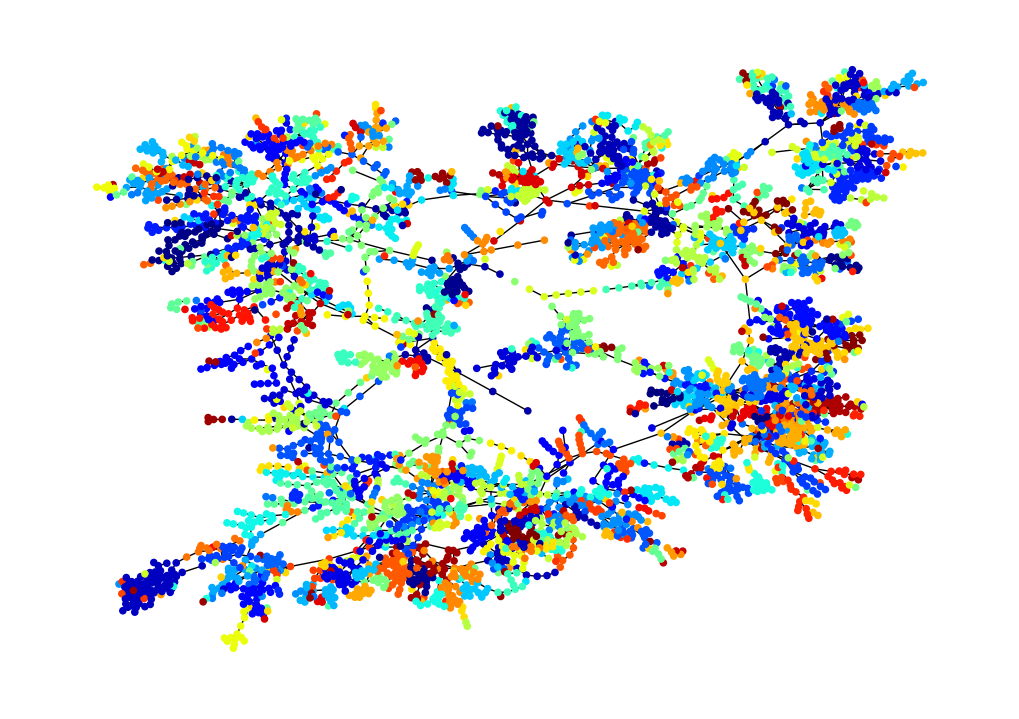

torch.Size([2, 9234])


In [9]:
plot(data, clusters_2)

In [10]:
unique, counts = np.unique(clusters, return_counts=True)

class_counts = np.asarray((unique, counts)).T

sorted_class_counts = class_counts[class_counts[:, 1].argsort()[::-1]]
print(sorted_class_counts)

[[294  84]
 [ 22  80]
 [209  65]
 [221  52]
 [ 25  51]
 [ 79  49]
 [ 11  47]
 [200  47]
 [145  46]
 [140  43]
 [  4  43]
 [ 18  42]
 [170  41]
 [ 84  39]
 [ 76  38]
 [179  38]
 [159  37]
 [ 53  36]
 [ 67  36]
 [ 43  36]
 [ 80  35]
 [134  35]
 [ 75  35]
 [ 69  34]
 [157  34]
 [ 89  34]
 [ 77  33]
 [ 42  32]
 [  2  32]
 [ 57  31]
 [108  31]
 [168  31]
 [ 35  30]
 [183  30]
 [ 90  30]
 [ 98  30]
 [204  29]
 [ 36  29]
 [ 99  29]
 [  9  29]
 [164  29]
 [278  29]
 [ 49  28]
 [ 48  28]
 [173  27]
 [ 19  27]
 [148  27]
 [151  27]
 [ 73  27]
 [ 40  27]
 [248  27]
 [166  27]
 [  3  26]
 [120  26]
 [274  25]
 [195  25]
 [128  25]
 [233  25]
 [216  24]
 [196  24]
 [247  23]
 [101  23]
 [160  23]
 [ 60  22]
 [113  22]
 [ 87  22]
 [ 70  21]
 [ 74  21]
 [137  21]
 [180  21]
 [293  20]
 [182  20]
 [272  20]
 [ 34  20]
 [117  20]
 [242  20]
 [275  20]
 [135  19]
 [ 61  19]
 [153  19]
 [177  19]
 [174  19]
 [229  19]
 [ 10  19]
 [256  19]
 [132  18]
 [161  18]
 [226  18]
 [290  18]
 [142  18]
 [150  18]

In [11]:
unique, counts = np.unique(clusters_2, return_counts=True)

class_counts = np.asarray((unique, counts)).T

sorted_class_counts = class_counts[class_counts[:, 1].argsort()[::-1]]
print(sorted_class_counts)

[[ 17  85]
 [ 40  68]
 [  7  53]
 [  2  49]
 [239  47]
 [209  39]
 [ 48  39]
 [ 60  39]
 [244  38]
 [ 36  35]
 [ 59  35]
 [ 19  35]
 [ 11  35]
 [229  35]
 [151  34]
 [ 64  33]
 [ 39  33]
 [134  33]
 [ 71  32]
 [ 15  32]
 [128  32]
 [ 83  31]
 [266  31]
 [ 54  30]
 [ 74  30]
 [ 27  30]
 [ 37  29]
 [  9  29]
 [ 53  29]
 [ 22  28]
 [105  28]
 [ 66  28]
 [ 79  27]
 [ 78  27]
 [217  27]
 [287  27]
 [159  26]
 [166  26]
 [ 81  26]
 [  4  26]
 [ 45  26]
 [ 23  26]
 [290  25]
 [132  25]
 [175  25]
 [ 20  25]
 [240  25]
 [ 97  24]
 [ 61  24]
 [ 24  24]
 [ 67  24]
 [ 26  24]
 [170  24]
 [138  24]
 [190  24]
 [224  23]
 [ 56  23]
 [ 43  23]
 [ 87  23]
 [ 80  22]
 [ 85  22]
 [ 99  22]
 [ 25  22]
 [248  22]
 [275  22]
 [ 31  22]
 [ 14  22]
 [127  22]
 [161  21]
 [207  21]
 [ 55  21]
 [  5  21]
 [198  21]
 [103  21]
 [ 89  21]
 [ 91  21]
 [ 16  21]
 [100  20]
 [ 18  20]
 [146  20]
 [121  20]
 [119  20]
 [ 92  20]
 [ 58  20]
 [249  20]
 [298  20]
 [ 21  20]
 [212  20]
 [197  20]
 [182  20]
 [176  20]

[104 165 143 ...  44 145 258]
[31 30 28 27 27 27 27 27 27 26 26 25 25 25 25 25 25 25 24 24 24 23 23 23
 23 23 23 23 23 23 23 23 22 22 22 22 22 22 22 22 22 21 21 21 21 21 21 21
 21 21 21 21 21 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20
 20 20 20 20 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19 19
 19 19 19 19 19 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18
 18 18 18 18 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17 17
 17 17 17 17 17 17 17 17 17 17 17 16 16 16 16 16 16 16 16 16 16 16 16 16
 16 16 16 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15
 15 15 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14
 14 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13 13
 13 13 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 11 11 11 11 11 11
 11 11 11 11 10 10 10 10 10 10 10 10 10 10 10  9  9  9  9  8  8  8  8  8
  8  8  7  7  7  7  6  6  5  5  5  5]


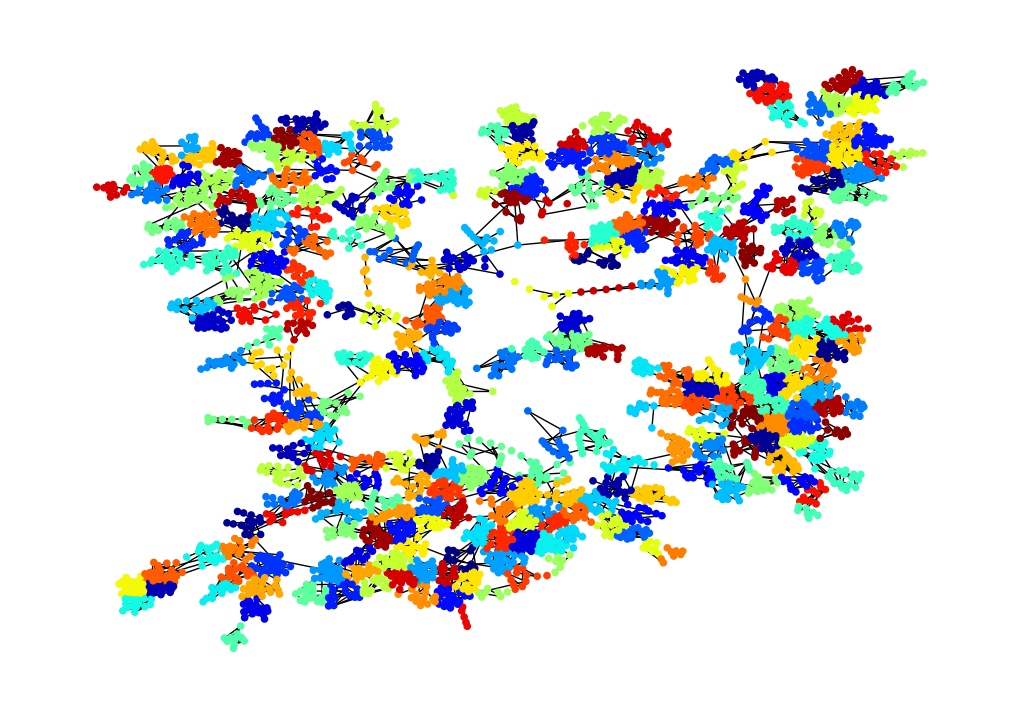

torch.Size([2, 8722])


In [12]:
import graph_tool.all as gt
from graph_tool.inference import BlockState


def removerepeated(ei: torch.Tensor) -> torch.Tensor:
    """
    remove bidirectional link

    Args:
        ei (torch.Tensor): edge_index

    Returns:
        torch.Tensor: directional edge_index
    """
    ei = to_undirected(ei)

    ei = ei[:, ei[0] < ei[1]]
    return ei


def to_graph_tool(data: Data) -> tuple[gt.Graph, gt.PropertyMap]:
    """
    transform graph from pyG to gt

    Args:
        data (Data): torch_geometric data

    Returns:
        tuple[gt.Graph, gt.PropertyMap]: gt graph and block map
    """
    ei = removerepeated(data.edge_index)

    G_gt = gt.Graph(directed=False)

    node_map = G_gt.new_vertex_property("int")
    block_map = G_gt.new_vertex_property("int")
    for i in range(data.num_nodes):
        v = G_gt.add_vertex()
        node_map[v] = i
        block_map[v] = data.block[i]

    for edge in ei.t().tolist():
        G_gt.add_edge(G_gt.vertex(node_map[edge[0]]), G_gt.vertex(node_map[edge[1]]))

    return G_gt, block_map



def gen_sbm_fast(data: Data, state: gt.BlockState) -> Data:
    """
    Generate SBM graph with graph tool

    Args:
        data (Data): Data from pyG
        state (gt.BlockState): BlockState of Data

    Returns:
        Data: new Data generated
    """
    gtG = state.sample_graph(canonical=True, self_loops=False, multigraph=False)
    edge_index = torch.from_numpy(gtG.get_edges().T)
    new_data = Data(edge_index=edge_index).to(data.edge_index.device)
    new_data.edge_index = to_undirected(new_data.edge_index)
    new_data.num_nodes = data.num_nodes
    new_data.sizes = data.sizes
    # new_data.probs = data.probs
    new_data.num_features = data.num_nodes
    return new_data

if hasattr(data, "_pos"):
    pos = []
    for p in data._pos:
        x, y = p.split(", ")
        pos.append([float(x), float(y)])
else:
    print("No Pos going to Node2Vec")
    # G = to_networkx(data, to_undirected=True)
    # pos = nx.spring_layout(G)
    # pos = [list(p) for p in pos.values()]
    model = Node2Vec(
        data.edge_index,
        embedding_dim=self.param['proj_hidden'],
        walk_length=20,
        context_size=10,
        walks_per_node=10,
        num_negative_samples=1,
        p=1.0,
        q=1.0,
        sparse=True,
    ).to(self.device)

    num_workers = os.cpu_count()
    loader = model.loader(batch_size=128, shuffle=True, num_workers=num_workers)
    optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)

    def train():
        model.train()
        total_loss = 0
        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()
            loss = model.loss(pos_rw.to(self.device), neg_rw.to(self.device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)



    for epoch in tqdm(range(1, 51), desc="Node2Vec"):
        loss = train()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')
    pos = torch.tensor(model()).cpu()

pos = np.array(pos)
kmeans = KMeans(n_clusters=300)
clusters = kmeans.fit_predict(pos)
print(clusters)
data.block = clusters
unique, counts = np.unique(clusters, return_counts=True)
data.sizes = np.sort(counts)[::-1]
print(data.sizes)

gtG, block_map = to_graph_tool(data)
data.state = BlockState(gtG, block_map, deg_corr=False)

new_data = gen_sbm_fast(data, data.state)
plot(new_data, clusters)

[2, 4, 7, 37, 43, 44, 45, 57, 63, 67, 74, 117, 121, 127, 130, 147, 165, 180, 183, 185, 188, 208, 209, 211, 217, 227, 248, 250, 273, 275, 289, 291, 303, 304, 307, 311, 329, 344, 358, 363, 372, 375, 382, 397, 404, 423, 450, 460, 465, 476, 477, 495, 498, 500, 512, 515, 517, 527, 569, 574, 581, 583, 591, 595, 596, 599, 600, 601, 602, 608, 611, 613, 619, 626, 629, 633, 646, 647, 659, 674, 678, 686, 690, 693, 697, 721, 723, 724, 727, 729, 733, 741, 745, 755, 768, 773, 775, 788, 792, 798, 799, 810, 841, 858, 865, 870, 879, 886, 888, 889, 893, 901, 903, 904, 909, 911, 913, 914, 915, 916, 919, 920, 922, 923, 938, 947, 957, 972, 976, 980, 985, 1004, 1015, 1029, 1043, 1062, 1113, 1138, 1180, 1185, 1188, 1193, 1202, 1211, 1228, 1264, 1266, 1281, 1287, 1288, 1317, 1318, 1344, 1354, 1375, 1392, 1411, 1412, 1414, 1420, 1444, 1464, 1482, 1483, 1509, 1534, 1550, 1552, 1560, 1593, 1594, 1604, 1606, 1607, 1615, 1618, 1629, 1641, 1650, 1655, 1674, 1683, 1708, 1720, 1735, 1739, 1750, 1764, 1768, 1773, 1792

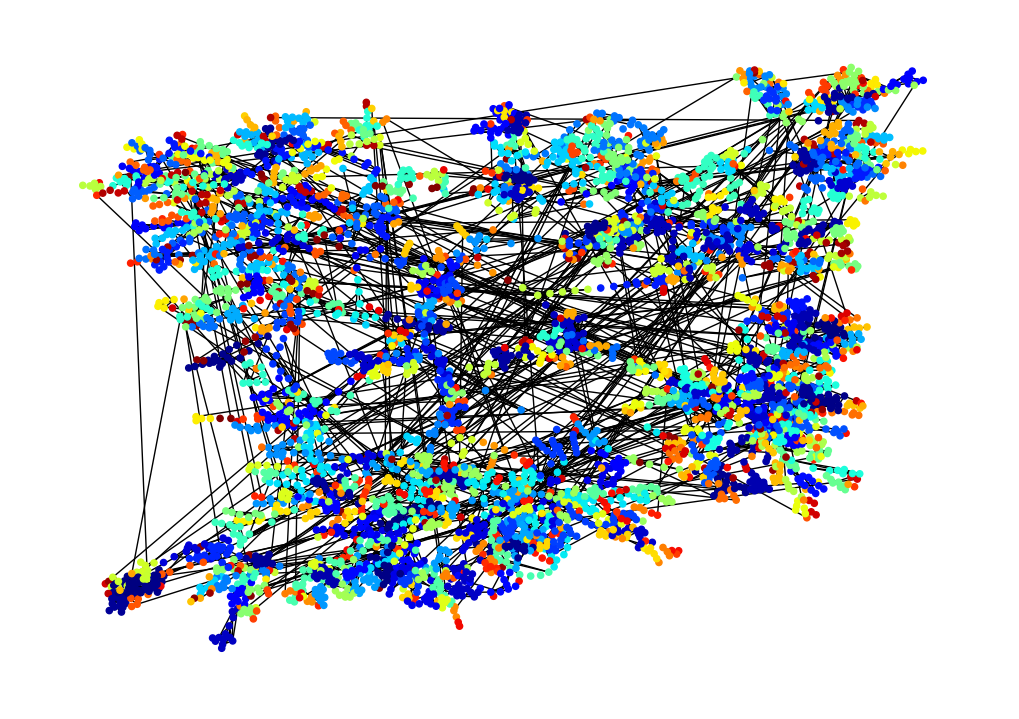

torch.Size([2, 7390])


[[4332,
  4334,
  4335,
  4336,
  4343,
  4345,
  4346,
  4347,
  4353,
  4360,
  4361,
  4373,
  4377,
  4381,
  4395,
  4396,
  4398,
  4402,
  4405,
  4406,
  4407,
  4409,
  4418,
  4419],
 [2430,
  2494,
  2520,
  2533,
  2534,
  2595,
  2659,
  2764,
  2765,
  2821,
  2823,
  3005,
  3008,
  3017,
  3056,
  3112,
  3157,
  3179,
  3209,
  3221,
  3269],
 [1074,
  1075,
  1076,
  1080,
  1158,
  1159,
  1217,
  1334,
  1380,
  1390,
  1391,
  1395,
  1396,
  1425,
  1502,
  1506,
  1514,
  1559,
  1684,
  1905],
 [1100,
  1101,
  1276,
  1277,
  1278,
  1279,
  1309,
  1436,
  1489,
  1814,
  1908,
  1920,
  2062,
  2120,
  2138,
  2139,
  2176,
  2179,
  2185,
  2198],
 [2530,
  2584,
  2596,
  2657,
  2693,
  2792,
  2843,
  2908,
  2916,
  2918,
  2926,
  2927,
  2928,
  2929,
  3077,
  3096,
  3171,
  3181,
  3285,
  3286],
 [937,
  939,
  940,
  954,
  956,
  974,
  984,
  1018,
  1019,
  1022,
  1023,
  1024,
  1031,
  1032,
  1046,
  1050,
  1051,
  1052,
  1059],
 [4327,
 

In [25]:
from cdlib import algorithms
import random
G = to_networkx(data, to_undirected=True)
clusters = algorithms.infomap(G).communities

alonode = []
for c in clusters:
    if len(c) == 1:
        alonode.extend(c)
print(alonode)
for n in alonode:
    clusters.remove([n])
    candidate_add = []
    for c in clusters:
        if len(c) <= 6 and len(c) > 1:
            candidate_add.append(c)
    c_select = random.choice(candidate_add)
    c_select.append(n)


block = np.empty((len(G.nodes)))

sizes = []
for idx, c in enumerate(clusters):
    sizes.append(len(c))
    for n in c:
        block[n] = idx
print(block)

data.block = block
data.sizes = sizes
print(sizes)

gtG, block_map = to_graph_tool(data)
data.state = BlockState(gtG, block_map, deg_corr=False)

new_data = gen_sbm_fast(data, data.state)
plot(new_data, block)
clusters

[ 67. 177. 227. ... 186. 143. 143.]
[36, 33, 30, 26, 25, 25, 25, 25, 25, 24, 24, 23, 23, 22, 22, 22, 21, 21, 21, 21, 20, 20, 20, 19, 19, 19, 19, 19, 19, 19, 19, 18, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9

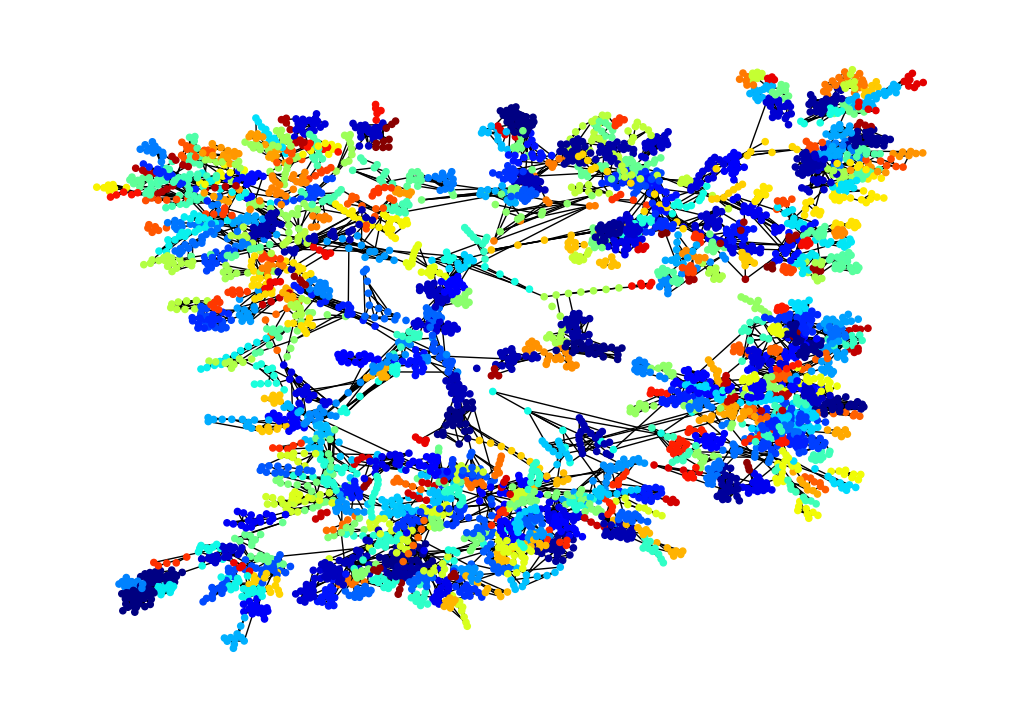

torch.Size([2, 11332])


In [29]:
from torch_geometric.utils import add_self_loops
ei_vt = to_undirected(torch.cat((split['train']['edge'], split['valid']['edge'], split['test']['edge'])).T)
# if  ei_vt.max().item() + 1 < data.num_nodes:
#     ei_vt = add_self_loops(ei_vt, num_nodes=data.num_nodes)[
#         0
#     ]
d_test = Data(edge_index=ei_vt)


G = to_networkx(d_test, to_undirected=True)
clusters = algorithms.infomap(G).communities
block = np.empty((len(G.nodes)))

sizes = []
for idx, c in enumerate(clusters):
    sizes.append(len(c))
    for n in c:
        block[n] = idx
print(block)

d_test.block = block
d_test.sizes = sizes
print(sizes)

gtG, block_map = to_graph_tool(d_test)
d_test.state = BlockState(gtG, block_map, deg_corr=False)


new_data = gen_sbm_fast(d_test, d_test.state)
plot(new_data, block)